# This is the initial preprocessing notebook. After downloading the public datasets, I took random samples in order to curate a dataset with a size equal to the one used in the paper and I also created training, validation and test splits and saved them in a file/directory format used by pytorch

## First take a random subset of the original Dataset to match the size of dataset (https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/data) used in the paper. Authors used 95 Tumor images and 94 non-Tumor images but public repository has 155 tumor images and 98 non-tumor images.

In [1]:
from pathlib import Path
import random
import shutil

In [2]:
yes_source = Path('../data/raw/yes')

In [3]:
no_source = Path('../data/raw/no')

In [4]:
yes_images = [image for image in yes_source.iterdir()]

In [5]:
no_images = [image for image in no_source.iterdir()]

In [6]:
print("Tumor images:", len(yes_images))
print("No-tumor images:", len(no_images))

Tumor images: 155
No-tumor images: 98


In [7]:
random.seed(100)

In [8]:
selected_yes = random.sample(yes_images, 95)
selected_no = random.sample(no_images, 94)

print("Selected tumor images:", len(selected_yes))
print("Selected no-tumor images:", len(selected_no))

Selected tumor images: 95
Selected no-tumor images: 94


In [9]:
yes_output = Path('../data/Yes')
no_output = Path('../data/No')

In [10]:
for image in selected_yes:
    shutil.copy(image, yes_output / image.name)

for image in selected_no:
    shutil.copy(image, no_output / image.name)

print("Finished copying images.")

Finished copying images.


Inspect a few images

Image size: (225, 225)
Image mode: RGB


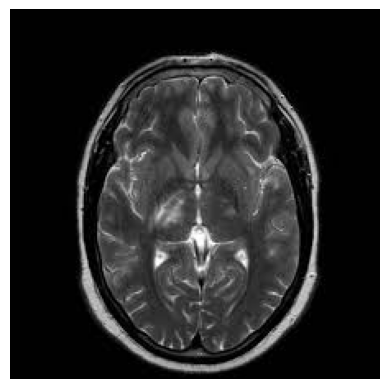

In [43]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = selected_no[49]
image = Image.open(image_path)

print("Image size:", image.size)
print("Image mode:", image.mode)

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

## Here we shuffle the order and create the splits

In [216]:
random.seed(100)
shuffle_yes = random.sample(selected_yes, k=len(selected_yes))
shuffle_no = random.sample(selected_no, k=len(selected_no))

In [217]:
train_yes = shuffle_yes[0:67]
val_yes = shuffle_yes[67:81]
test_yes = shuffle_yes[81:]

In [218]:
print(len(train_yes), len(val_yes),len(test_yes))

67 14 14


In [219]:
train_no = shuffle_no[0:66]
val_no = shuffle_no[66:80]
test_no = shuffle_no[80:]

In [220]:
print(len(train_no), len(val_no),len(test_no))

66 14 14


In [221]:
for image in train_yes:
    shutil.copy(image,Path('../data/splits/train/yes') / image.name)

In [222]:
for image in val_yes:
    shutil.copy(image,Path('../data/splits/validation/yes') / image.name)

In [223]:
for image in test_yes:
    shutil.copy(image,Path('../data/splits/test/yes') / image.name)

In [224]:
for image in train_no:
    shutil.copy(image,Path('../data/splits/train/no') / image.name)

In [225]:
for image in val_no:
    shutil.copy(image,Path('../data/splits/validation/no') / image.name)

In [226]:
for image in test_no:
    shutil.copy(image,Path('../data/splits/test/no') / image.name)